In [1]:
# Run this once per Colab session
!git clone https://github.com/adityarahi/Recommender-System-Project.git
%cd Recommender-System-Project
!pip install -r requirements.txt
!python data/download_data.py

Cloning into 'Recommender-System-Project'...
remote: Enumerating objects: 22, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 22 (delta 3), reused 22 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (22/22), 127.36 KiB | 1.22 MiB/s, done.
Resolving deltas: 100% (3/3), done.
/content/Recommender-System-Project
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 58.5 MB/s eta 0:00:00
Extracting...
Dataset ready at /content/Recommender-System-Project/data/raw/ml-100k/


# Memory-Based Collaborative Filtering

Evaluate User-KNN and Item-KNN across:
- Similarity measures: cosine vs. Pearson / adjusted-cosine
- Neighbourhood sizes: K = 10, 20, 40
- Metrics: RMSE, MAE, Precision@10, Recall@10, NDCG@10

In [2]:
import sys, os

# Works both locally (run from notebooks/) and on Google Colab (run from repo root)
_src = os.path.join('..', 'src') if os.path.isdir(os.path.join('..', 'src')) else 'src'
_data = os.path.join('..', 'data', 'processed') if os.path.isdir(os.path.join('..', 'data')) else os.path.join('data', 'processed')
sys.path.insert(0, _src)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import get_data
from memory_based.user_based_cf import UserBasedCF
from memory_based.item_based_cf import ItemBasedCF
from evaluation.metrics import evaluate_predictions, evaluate_ranking, catalog_coverage

sns.set_theme(style='whitegrid')
%matplotlib inline

In [3]:
train, test, matrix, movies = get_data()
print(f'Train: {len(train):,}  Test: {len(test):,}  Matrix: {matrix.shape}')

Train: 79,619  Test: 20,381  Matrix: (943, 1650)


## Helper: build test-relevant sets

A test item is *relevant* if the user rated it ≥ 4 stars.

In [4]:
RELEVANCE_THRESHOLD = 4
K = 10
N_ITEMS = matrix.shape[1]
ALL_ITEMS = list(matrix.columns)

test_relevant = (
    test[test['rating'] >= RELEVANCE_THRESHOLD]
    .groupby('user_id')['item_id']
    .apply(set)
    .to_dict()
)

def get_rated(user_id, train_df):
    return set(train_df[train_df['user_id'] == user_id]['item_id'])

## 1. User-Based CF

In [5]:
results = []

for sim in ['cosine', 'pearson']:
    for k in [10, 20, 40]:
        print(f'User-KNN  sim={sim}  k={k} ...', end=' ')
        model = UserBasedCF(k=k, similarity=sim).fit(matrix)

        # Rating prediction
        test['predicted'] = model.predict_batch(test)
        pred_metrics = evaluate_predictions(test, pred_col='predicted')

        # Top-N ranking
        test_users = test['user_id'].unique()
        recs = {}
        for uid in test_users:
            rated = get_rated(uid, train)
            recs[uid] = model.recommend(uid, n=K)

        rank_metrics = evaluate_ranking(recs, test_relevant, k=K)
        cov = catalog_coverage(list(recs.values()), N_ITEMS)

        results.append({'Model': 'User-KNN', 'Similarity': sim, 'K': k,
                        **pred_metrics, **rank_metrics, 'Coverage': cov})
        print(f"RMSE={pred_metrics['RMSE']:.4f}  NDCG@10={rank_metrics['NDCG@10']:.4f}")

results_df = pd.DataFrame(results)
results_df

User-KNN  sim=cosine  k=10 ... RMSE=0.9529  NDCG@10=0.0343
User-KNN  sim=cosine  k=20 ... RMSE=0.9404  NDCG@10=0.0255
User-KNN  sim=cosine  k=40 ... RMSE=0.9401  NDCG@10=0.0169
User-KNN  sim=pearson  k=10 ... RMSE=0.9461  NDCG@10=0.0238
User-KNN  sim=pearson  k=20 ... RMSE=0.9333  NDCG@10=0.0185
User-KNN  sim=pearson  k=40 ... RMSE=0.9312  NDCG@10=0.0135


,Model,Similarity,K,RMSE,MAE,Precision@10,Recall@10,NDCG@10,Coverage
0,User-KNN,cosine,10,0.952910,0.742613,0.027678,0.020226,0.034286,0.132727
1,User-KNN,cosine,20,0.940414,0.733387,0.020467,0.017384,0.025501,0.101212
2,User-KNN,cosine,40,0.940120,0.733582,0.012513,0.009958,0.016932,0.083636
3,User-KNN,pearson,10,0.946076,0.734691,0.018876,0.013768,0.023817,0.222424
4,User-KNN,pearson,20,0.933338,0.725864,0.013998,0.009791,0.018539,0.186061
5,User-KNN,pearson,40,0.931223,0.725382,0.009438,0.008630,0.013497,0.180000


## 2. Item-Based CF

In [7]:
item_results = []

for sim in ['cosine', 'adjusted_cosine']:
    for k in [10, 20, 40]:
        print(f'Item-KNN  sim={sim}  k={k} ...', end=' ')
        model = ItemBasedCF(k=k, similarity=sim).fit(matrix)

        test['predicted'] = model.predict_batch(test)
        pred_metrics = evaluate_predictions(test, pred_col='predicted')

        recs = {}
        for uid in test['user_id'].unique():
            recs[uid] = model.recommend(uid, n=K)

        rank_metrics = evaluate_ranking(recs, test_relevant, k=K)
        cov = catalog_coverage(list(recs.values()), N_ITEMS)

        item_results.append({'Model': 'Item-KNN', 'Similarity': sim, 'K': k,
                              **pred_metrics, **rank_metrics, 'Coverage': cov})
        print(f"RMSE={pred_metrics['RMSE']:.4f}  NDCG@10={rank_metrics['NDCG@10']:.4f}")

item_results_df = pd.DataFrame(item_results)
item_results_df

Item-KNN  sim=cosine  k=10 ... RMSE=0.9680  NDCG@10=0.0457
Item-KNN  sim=cosine  k=20 ... RMSE=0.9705  NDCG@10=0.0396
Item-KNN  sim=cosine  k=40 ... RMSE=0.9832  NDCG@10=0.0281
Item-KNN  sim=adjusted_cosine  k=10 ... RMSE=0.9382  NDCG@10=0.0409
Item-KNN  sim=adjusted_cosine  k=20 ... RMSE=0.9290  NDCG@10=0.0340
Item-KNN  sim=adjusted_cosine  k=40 ... RMSE=0.9289  NDCG@10=0.0237


,Model,Similarity,K,RMSE,MAE,Precision@10,Recall@10,NDCG@10,Coverage
0,Item-KNN,cosine,10,0.967965,0.752829,0.041888,0.022559,0.045656,0.806667
1,Item-KNN,cosine,20,0.970478,0.757020,0.039236,0.016750,0.039592,0.673939
2,Item-KNN,cosine,40,0.983172,0.771038,0.029480,0.011237,0.028085,0.537576
3,Item-KNN,adjusted_cosine,10,0.938208,0.728817,0.041569,0.019521,0.040891,0.764848
4,Item-KNN,adjusted_cosine,20,0.929017,0.724341,0.037752,0.016018,0.033992,0.710909
5,Item-KNN,adjusted_cosine,40,0.928949,0.726812,0.027359,0.010593,0.023715,0.680606


## 3. Best configurations — side-by-side

In [8]:
all_results = pd.concat([results_df, item_results_df], ignore_index=True)
all_results.sort_values('RMSE').to_csv(os.path.join(_data, 'memory_based_results.csv'), index=False)

# Best per model type
best = all_results.loc[all_results.groupby('Model')['RMSE'].idxmin()]
best[['Model', 'Similarity', 'K', 'RMSE', 'MAE', 'Precision@10', 'Recall@10', 'NDCG@10', 'Coverage']]

,Model,Similarity,K,RMSE,MAE,Precision@10,Recall@10,NDCG@10,Coverage
11,Item-KNN,adjusted_cosine,40,0.928949,0.726812,0.027359,0.010593,0.023715,0.680606
5,User-KNN,pearson,40,0.931223,0.725382,0.009438,0.008630,0.013497,0.180000


## 4. Effect of K on RMSE

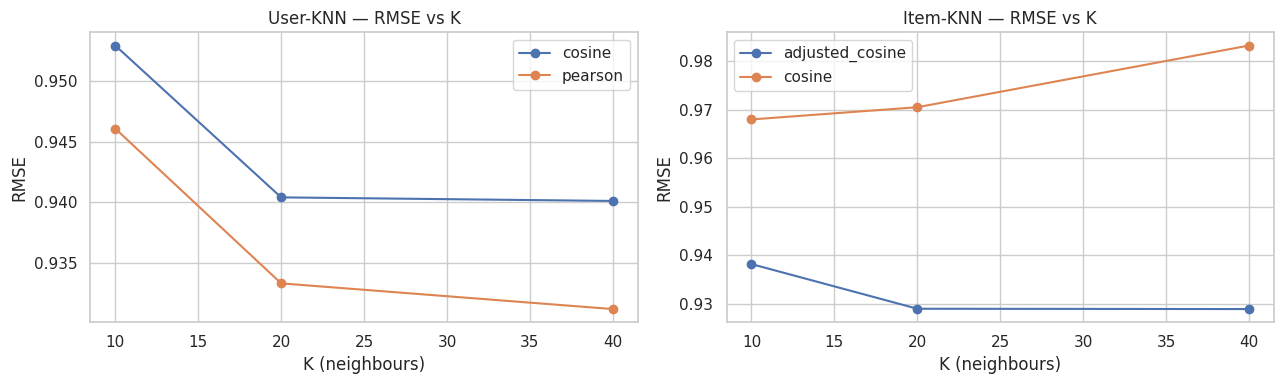

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, model_name, res in zip(axes, ['User-KNN', 'Item-KNN'], [results_df, item_results_df]):
    for sim, grp in res.groupby('Similarity'):
        ax.plot(grp['K'], grp['RMSE'], marker='o', label=sim)
    ax.set_title(f'{model_name} — RMSE vs K')
    ax.set_xlabel('K (neighbours)')
    ax.set_ylabel('RMSE')
    ax.legend()

plt.tight_layout()
plt.show()

## 5. Sample recommendations for a user

In [10]:
SAMPLE_USER = 1

best_user_model = UserBasedCF(k=20, similarity='pearson').fit(matrix)
top10 = best_user_model.recommend(SAMPLE_USER, n=10)

print(f'Top-10 recommendations for user {SAMPLE_USER} (User-KNN, Pearson, K=20):')
movies[movies['item_id'].isin(top10)][['item_id', 'title']]

Top-10 recommendations for user 1 (User-KNN, Pearson, K=20):


,item_id,title
168,169,"Wrong Trousers, The (1993)"
813,814,"Great Day in Harlem, A (1994)"
850,851,Two or Three Things I Know About Her (1966)
867,868,Hearts and Minds (1996)
1466,1467,"Saint of Fort Washington, The (1993)"
1553,1554,Safe Passage (1994)
1598,1599,Someone Else's America (1995)
1627,1628,Lamerica (1994)
1641,1642,Some Mother's Son (1996)
1652,1653,Entertaining Angels: The Dorothy Day Story (1996)
